A stock whose price is $30 has an expected return of 9% and a volatility of 20%. In
Excel, simulate the stock price path over 5 years using monthly time steps and random
samples from a normal distribution. Chart the simulated stock price path. By hitting F9,
observe how the path changes as the random samples change.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

### Normal Approach

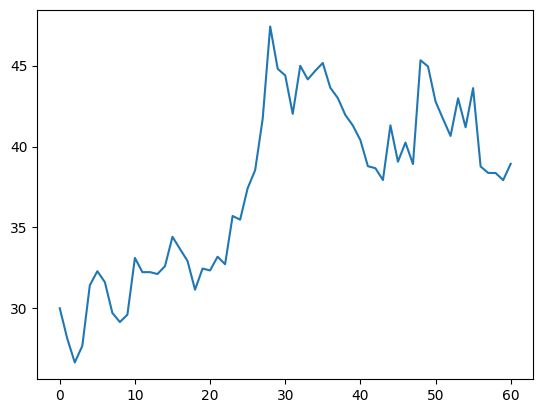

In [22]:
S_0 = 30 # $
mean = 0.09 # %
dt = 1/12 # month
variance = 0.20 # %
def dS(S, dt, mean, variance):
    noise = np.random.normal(0,1)
    return S * mean * dt + S * variance * noise * np.sqrt(dt)

S_i = [S_0]
for i in range(5 * 12):
    S_i.append(S_i[-1] + dS(S_i[-1], dt, mean, variance))
S_i = np.array(S_i)

plt.plot(np.arange(0, 5 * 12 + 1), S_i)
plt.show()

### Vectorized Approach

For stocks, if $G = \ln S$
$$ dG \sim \mathcal{N}\bigg(\mu - \frac{\sigma^2}{2}, \sigma^2\bigg)$$
$$ dG = \bigg(\mu - \frac{\sigma^2}{2}\bigg)dt + \sigma dz$$

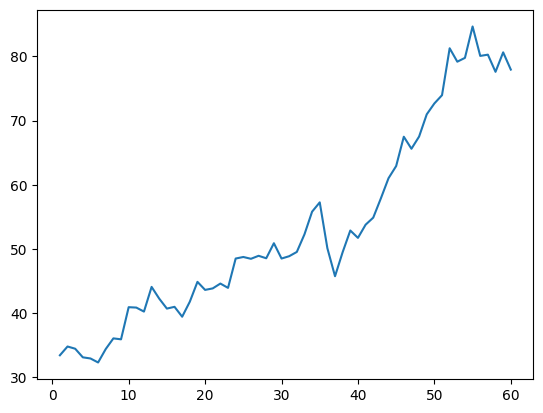

In [34]:
S_0 = 30 # $
mean = 0.09 # %
dt = 1/12 # month
sigma = 0.20 # %

dG = (mean - sigma**2/2) * dt + sigma * np.sqrt(dt) * np.random.normal(0, 1, 5 * 12)
G = np.log(S_0) + np.cumsum(dG) 
S = np.exp(G)

plt.plot(np.arange(1, 5 * 12 + 1), S)
plt.show()